# 07 — Logistic Regression
### From Linear Discriminants to Maximum-Likelihood Classification

---

> **Position in the series:**
> `01_statistical_learning_theory` → `02_pac_and_vc_dimensions` → `03_linear_algebra_and_geometry` → `04_pca` → `05_gaussian_mixture_models` → `06_linear_regression` → **`07_logistic_regression`** → `08_svm_and_kernel_methods`

---

## References

| # | Source |
|---|--------|
| [1] | Andrew Ng — *CS229 Lecture Notes*, Part I (Classification & Logistic Regression) and Part III (Generative Learning Algorithms), Stanford (2019) |
| [2] | Iacopo Masi — classification lecture slides & notebook, Sapienza SMIA |
| [3] | C. M. Bishop — *Pattern Recognition and Machine Learning*, Springer, 2006 — Ch. 4 (Linear Models for Classification) |
| [4] | T. Hastie, R. Tibshirani & J. Friedman — *The Elements of Statistical Learning*, 2nd ed., Springer, 2009 — Ch. 4 |
| [5] | S. Shalev-Shwartz & S. Ben-David — *Understanding Machine Learning*, Cambridge, 2014 — Ch. 9 (Linear Predictors) |
| [6] | T. M. Mitchell — *Generative and Discriminative Classifiers: Naive Bayes and Logistic Regression*, draft chapter, *Machine Learning* |
| [7] | G. H. Golub & C. F. Van Loan — *Matrix Computations*, 4th ed., Johns Hopkins, 2013 *(Newton's Method)* |
| [8] | D. W. Hosmer, S. Lemeshow & R. X. Sturdivant — *Applied Logistic Regression*, 3rd ed., Wiley, 2013 *(Diagnostics, ROC/AUC)* |

---

## Structure
1. From Regression to Classification: Why RSS on $\{0,1\}$ Fails
2. The Sigmoid Function: Log-Odds and the Logit Link
3. Probabilistic Model: Bernoulli Likelihood
4. The Linear Decision Boundary
5. Maximum Likelihood & the Cross-Entropy Loss
6. Convexity: The Hessian of the Log-Likelihood
7. Gradient of the Log-Likelihood — No Closed Form
8. Newton-Raphson & Iteratively Reweighted Least Squares (IRLS)
9. Gradient Descent for Logistic Regression
10. $L_2$-Regularized Logistic Regression — MAP Estimation
11. Multiclass: Softmax Regression
12. Generative vs. Discriminative: Naive Bayes vs. Logistic Regression
13. Evaluation: Confusion Matrix, Precision/Recall, ROC-AUC
14. Full Comparison: Linear vs. Polynomial vs. Regularized Boundaries


---
## 1. From Regression to Classification: Why RSS on $\{0,1\}$ Fails

In **binary classification** the target is no longer continuous: $y_i \in \{0,1\}$, and we want to estimate $P(y=1\mid\mathbf{x})$.

A naive idea: reuse Linear Regression from `06_linear_regression`, fit $\hat{y}=\mathbf{w}^T\mathbf{x}$, and threshold at $0.5$. Two problems arise:

* **Unbounded output:** $\mathbf{w}^T\mathbf{x}\in(-\infty,\infty)$, but probabilities must live in $[0,1]$. Nothing prevents nonsensical predictions like $\hat{y}=1.8$.
* **Sensitivity to well-classified outliers:** RSS penalizes *distance from the fitted line*, so a point that is already correctly classified but lies far from the bulk of the data still contributes a large loss and can *rotate* the decision boundary away from the optimal separator (Bishop, Fig. 4.4 [3]).

> **ML Bridge:** We keep the linear predictor $z=\mathbf{w}^T\mathbf{x}$ from `06_linear_regression` unchanged — the augmented vector trick ($x_0=1$) still applies. What changes is *what we do with* $z$ before comparing it to the label.


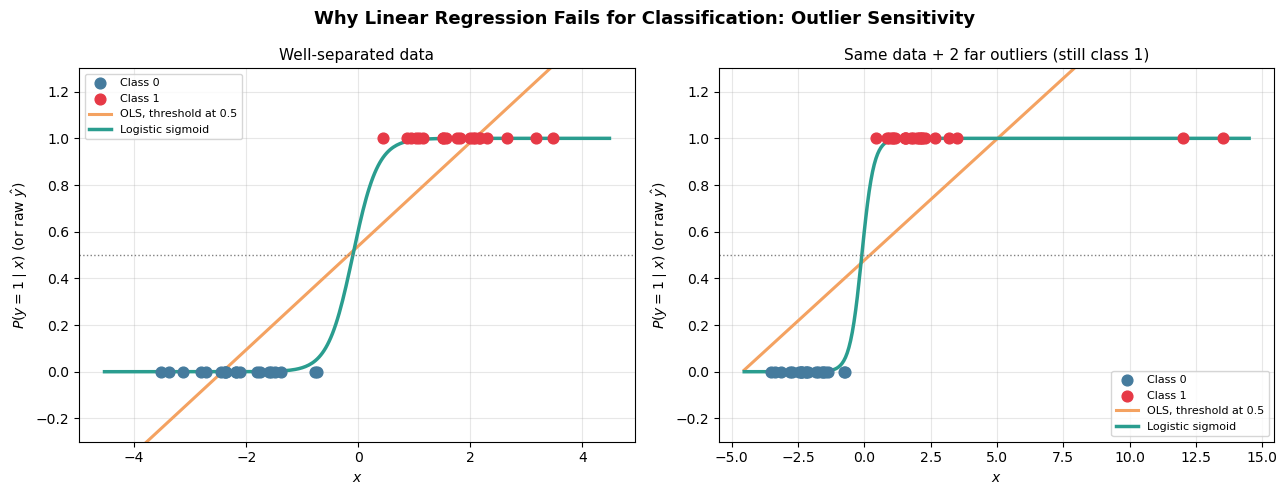

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Two well-separated 1D clusters (label 0 and label 1) ---
x0 = np.random.normal(-2, 0.8, 20)
x1 = np.random.normal( 2, 0.8, 20)
y0 = np.zeros_like(x0)
y1 = np.ones_like(x1)

# Same class-1 cluster, but with two points dragged far to the right.
# They are still unambiguously class 1 -- a good classifier should ignore them.
x1_outlier = np.concatenate([x1, [12.0, 13.5]])
y1_outlier = np.ones_like(x1_outlier)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def fit_ols_1d(x, y):
    """Closed-form OLS fit y = w0 + w1*x (Normal Equations, see 06_linear_regression)."""
    X = np.column_stack([np.ones_like(x), x])
    return np.linalg.lstsq(X, y, rcond=None)[0]

def fit_logistic_1d(x, y, n_iter=500, lr=0.5):
    """Logistic regression via plain gradient descent (derived in Section 9)."""
    X = np.column_stack([np.ones_like(x), x])
    w = np.zeros(2)
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        grad = X.T @ (p - y) / len(y)
        w -= lr * grad
    return w

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scenarios = [(x1, y1, 'Well-separated data'),
             (x1_outlier, y1_outlier, 'Same data + 2 far outliers (still class 1)')]

for ax, (x1_data, y1_data, title) in zip(axes, scenarios):
    x_all = np.concatenate([x0, x1_data])
    y_all = np.concatenate([y0, y1_data])
    w_ols = fit_ols_1d(x_all, y_all)
    w_log = fit_logistic_1d(x_all, y_all)

    x_plot = np.linspace(x_all.min()-1, x_all.max()+1, 300)
    ax.scatter(x0, y0, s=60, color='#457B9D', zorder=5, label='Class 0')
    ax.scatter(x1_data, y1_data, s=60, color='#E63946', zorder=5, label='Class 1')
    ax.plot(x_plot, w_ols[0]+w_ols[1]*x_plot, '#F4A261', lw=2.2, label='OLS, threshold at 0.5')
    ax.plot(x_plot, sigmoid(w_log[0]+w_log[1]*x_plot), '#2A9D8F', lw=2.5, label='Logistic sigmoid')
    ax.axhline(0.5, color='gray', lw=1, linestyle=':')
    ax.set_ylim(-0.3, 1.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x$'); ax.set_ylabel(r'$P(y=1\mid x)$ (or raw $\hat y$)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Why Linear Regression Fails for Classification: Outlier Sensitivity', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 2. The Sigmoid Function: Log-Odds and the Logit Link

We need a map $g:\mathbb{R}\to(0,1)$. Start from the **odds** of an event, $\dfrac{p}{1-p}$, and take the **log-odds** (the *logit*):

$$\text{logit}(p) = \ln\frac{p}{1-p} = z = \mathbf{w}^T\mathbf{x}$$

Solving for $p$ gives the **logistic (sigmoid) function**:

$$p = \frac{1}{1+e^{-z}} \;\equiv\; \boxed{\sigma(z) = \frac{1}{1+e^{-z}}}$$

This is the canonical *inverse link function* of the Bernoulli Generalized Linear Model (GLM).

### Key Properties
* **Range:** $\sigma(z)\in(0,1)$ for all $z\in\mathbb{R}$; $\sigma(0)=0.5$.
* **Symmetry:** $\sigma(-z) = 1-\sigma(z)$.
* **Derivative** (self-referential — the key identity behind the gradient in Section 7):

$$\sigma'(z) = \sigma(z)\big(1-\sigma(z)\big)$$

* **Saturation:** $\sigma'(z)\to 0$ as $|z|\to\infty$ — the seed of the *vanishing gradient* phenomenon later encountered in deep networks.


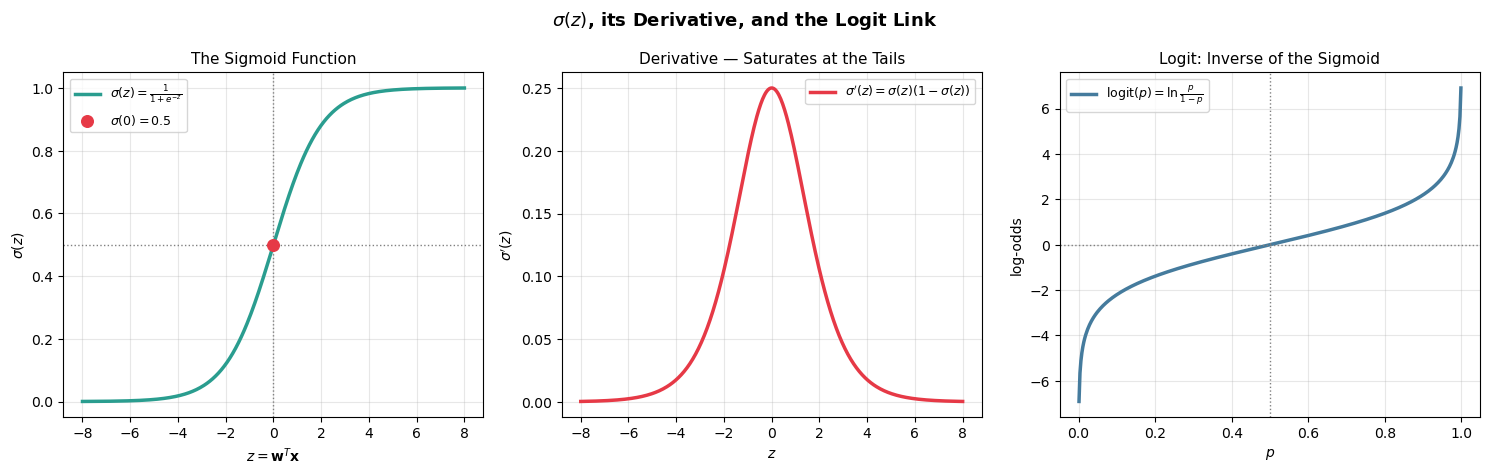

=== Derivative Sanity Check ===
Closed form  sigma'(z0) = 0.16829836
Finite diff  sigma'(z0) = 0.16829836
Match: True


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)          # closed-form derivative: sigma'(z) = sigma(z) (1-sigma(z))

z = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
ax.plot(z, sigmoid(z), '#2A9D8F', lw=2.5, label=r'$\sigma(z)=\frac{1}{1+e^{-z}}$')
ax.axhline(0.5, color='gray', lw=1, linestyle=':')
ax.axvline(0, color='gray', lw=1, linestyle=':')
ax.scatter([0], [0.5], s=70, color='#E63946', zorder=5, label=r'$\sigma(0)=0.5$')
ax.set_title('The Sigmoid Function', fontsize=11)
ax.set_xlabel(r'$z=\mathbf{w}^T\mathbf{x}$'); ax.set_ylabel(r'$\sigma(z)$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(z, sigmoid_grad(z), '#E63946', lw=2.5, label=r"$\sigma'(z)=\sigma(z)(1-\sigma(z))$")
ax2.set_title('Derivative — Saturates at the Tails', fontsize=11)
ax2.set_xlabel('$z$'); ax2.set_ylabel(r"$\sigma'(z)$")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
p = np.linspace(0.001, 0.999, 400)
ax3.plot(p, np.log(p/(1-p)), '#457B9D', lw=2.5, label=r'logit$(p)=\ln\frac{p}{1-p}$')
ax3.axhline(0, color='gray', lw=1, linestyle=':'); ax3.axvline(0.5, color='gray', lw=1, linestyle=':')
ax3.set_title('Logit: Inverse of the Sigmoid', fontsize=11)
ax3.set_xlabel('$p$'); ax3.set_ylabel('log-odds')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.suptitle(r'$\sigma(z)$, its Derivative, and the Logit Link', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Numerical sanity check: compare the closed-form derivative to a central finite difference
z0 = 1.3
h = 1e-6
fd = (sigmoid(z0+h) - sigmoid(z0-h)) / (2*h)
print('=== Derivative Sanity Check ===')
print(f"Closed form  sigma'(z0) = {sigmoid_grad(z0):.8f}")
print(f"Finite diff  sigma'(z0) = {fd:.8f}")
print(f'Match: {np.isclose(sigmoid_grad(z0), fd, atol=1e-6)}')


---
## 3. Probabilistic Model: Bernoulli Likelihood

Each label is modeled as a **Bernoulli trial** whose success probability is given by the sigmoid of the linear score:

$$P(y=1\mid\mathbf{x};\mathbf{w}) = \sigma(\mathbf{w}^T\mathbf{x}), \qquad P(y=0\mid\mathbf{x};\mathbf{w}) = 1-\sigma(\mathbf{w}^T\mathbf{x})$$

Both cases are captured compactly in a single differentiable expression — the trick that makes the log-likelihood tractable:

$$\boxed{P(y\mid\mathbf{x};\mathbf{w}) = \sigma(\mathbf{w}^T\mathbf{x})^{y}\,\big[1-\sigma(\mathbf{w}^T\mathbf{x})\big]^{1-y}}, \qquad y\in\{0,1\}$$

Check: for $y=1$ this reduces to $\sigma(z)$; for $y=0$ it reduces to $1-\sigma(z)$.

> **Connection to `06_linear_regression`:** there we assumed $y\mid\mathbf{x}\sim\mathcal{N}(\mathbf{w}^T\mathbf{x},\sigma^2)$ — a *continuous* exponential-family distribution with the identity link. Here $y\mid\mathbf{x}\sim\text{Bernoulli}(\sigma(\mathbf{w}^T\mathbf{x}))$ — a *discrete* exponential-family distribution with the logit link. Both are instances of the same **Generalized Linear Model (GLM)** construction.


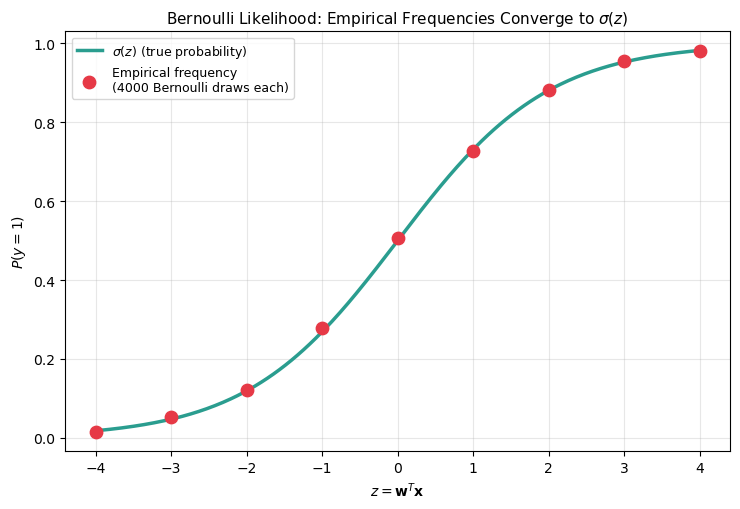

=== Law of Large Numbers Check ===
z=-4.0  sigma(z)=0.0180  empirical=0.0147  |diff|=0.0032
z=-3.0  sigma(z)=0.0474  empirical=0.0520  |diff|=0.0046
z=-2.0  sigma(z)=0.1192  empirical=0.1205  |diff|=0.0013
z=-1.0  sigma(z)=0.2689  empirical=0.2780  |diff|=0.0091
z=+0.0  sigma(z)=0.5000  empirical=0.5065  |diff|=0.0065
z=+1.0  sigma(z)=0.7311  empirical=0.7262  |diff|=0.0048
z=+2.0  sigma(z)=0.8808  empirical=0.8828  |diff|=0.0020
z=+3.0  sigma(z)=0.9526  empirical=0.9545  |diff|=0.0019
z=+4.0  sigma(z)=0.9820  empirical=0.9815  |diff|=0.0005


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

np.random.seed(5)
z_values = np.linspace(-4, 4, 9)
n_trials = 4000

# For each fixed score z, draw many Bernoulli(sigma(z)) samples and check that
# the empirical success frequency converges to sigma(z) -- the Law of Large Numbers.
empirical_p = []
for z in z_values:
    p_true = sigmoid(z)
    draws = np.random.binomial(1, p_true, n_trials)
    empirical_p.append(draws.mean())

fig, ax = plt.subplots(figsize=(7.5, 5.2))
z_fine = np.linspace(-4, 4, 300)
ax.plot(z_fine, sigmoid(z_fine), '#2A9D8F', lw=2.5, label=r'$\sigma(z)$ (true probability)')
ax.scatter(z_values, empirical_p, s=80, color='#E63946', zorder=5,
           label=f'Empirical frequency\n({n_trials} Bernoulli draws each)')
ax.set_xlabel(r'$z=\mathbf{w}^T\mathbf{x}$'); ax.set_ylabel('$P(y=1)$')
ax.set_title(r'Bernoulli Likelihood: Empirical Frequencies Converge to $\sigma(z)$', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('=== Law of Large Numbers Check ===')
for z, p_hat in zip(z_values, empirical_p):
    print(f'z={z:+.1f}  sigma(z)={sigmoid(z):.4f}  empirical={p_hat:.4f}  |diff|={abs(sigmoid(z)-p_hat):.4f}')


---
## 4. The Linear Decision Boundary

Classify by thresholding the predicted probability at $0.5$:

$$\hat{y}=1 \iff \sigma(\mathbf{w}^T\mathbf{x}) \geq 0.5 \iff \mathbf{w}^T\mathbf{x}\geq 0 \quad\text{(since $\sigma$ is monotonic and $\sigma(0)=0.5$)}$$

The **decision boundary** is therefore the hyperplane

$$\boxed{\mathbf{w}^T\mathbf{x} = 0}$$

a **linear** separator in $\mathbf{x}$-space, even though the *probability surface* $\sigma(\mathbf{w}^T\mathbf{x})$ is a smooth sigmoidal ramp along the direction of $\mathbf{w}$, and is constant on every hyperplane parallel to the boundary. As in `03_linear_algebra_and_geometry`, the (unsigned) distance from a point to the boundary is $\dfrac{|\mathbf{w}^T\mathbf{x}|}{\|\mathbf{w}\|_2}$.


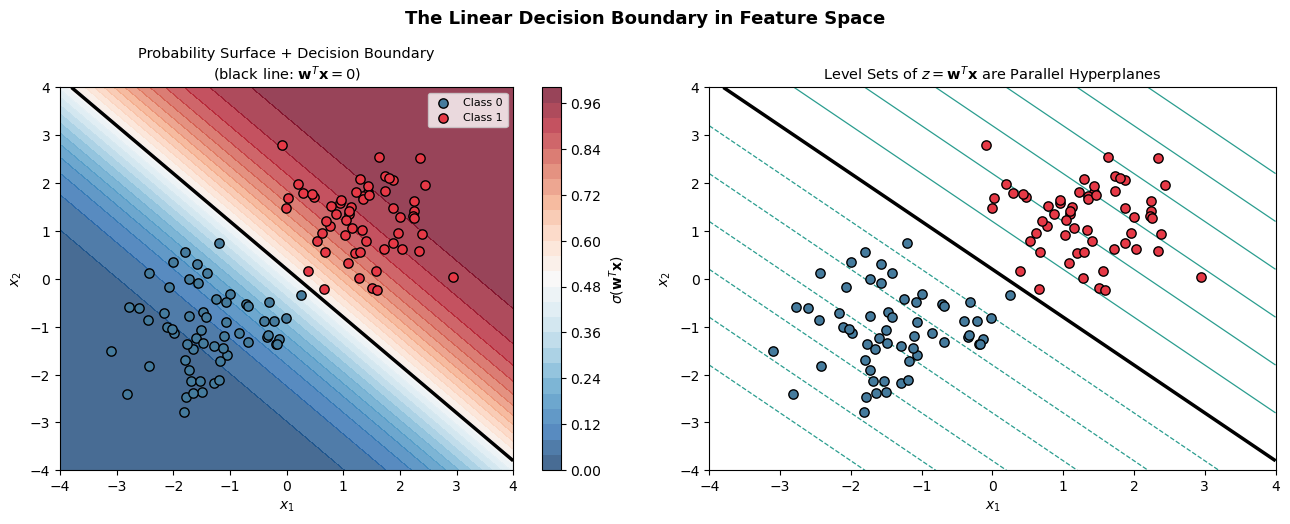

Distance of the first 5 points to the boundary: [1.238 1.668 2.34  2.871 1.023]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

np.random.seed(7)
N = 60
mean0, mean1 = np.array([-1.5, -1.0]), np.array([1.5, 1.2])
X0 = np.random.multivariate_normal(mean0, 0.6*np.eye(2), N)
X1 = np.random.multivariate_normal(mean1, 0.6*np.eye(2), N)

w_true = np.array([-0.2, 1.0, 1.0])   # [bias, w1, w2] -- a reasonable separator for this synthetic setup

xx, yy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
X_grid = np.column_stack([np.ones(xx.size), xx.ravel(), yy.ravel()])
Z_lin  = (X_grid @ w_true).reshape(xx.shape)   # z = w^T x -- linear score (whose level sets are hyperplanes)
Z_prob = sigmoid(Z_lin)                         # sigma(z) -- probability surface

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))

ax = axes[0]
cf = ax.contourf(xx, yy, Z_prob, levels=25, cmap='RdBu_r', alpha=0.75)
plt.colorbar(cf, ax=ax, label=r'$\sigma(\mathbf{w}^T\mathbf{x})$')
ax.contour(xx, yy, Z_lin, levels=[0.0], colors='black', linewidths=2.5)
ax.scatter(*X0.T, s=45, color='#457B9D', edgecolor='k', zorder=5, label='Class 0')
ax.scatter(*X1.T, s=45, color='#E63946', edgecolor='k', zorder=5, label='Class 1')
ax.set_title(r'Probability Surface + Decision Boundary' + '\n(black line: $\\mathbf{w}^T\\mathbf{x}=0$)', fontsize=10.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(fontsize=8)

ax2 = axes[1]
ax2.contour(xx, yy, Z_lin, levels=np.linspace(-6, 6, 13), colors='#2A9D8F', linewidths=0.9)
ax2.contour(xx, yy, Z_lin, levels=[0.0], colors='black', linewidths=2.5)
ax2.scatter(*X0.T, s=45, color='#457B9D', edgecolor='k', zorder=5)
ax2.scatter(*X1.T, s=45, color='#E63946', edgecolor='k', zorder=5)
ax2.set_title(r'Level Sets of $z=\mathbf{w}^T\mathbf{x}$ are Parallel Hyperplanes', fontsize=10.5)
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')

plt.suptitle('The Linear Decision Boundary in Feature Space', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

X_all = np.vstack([X0, X1])
dist = np.abs(np.column_stack([np.ones(len(X_all)), X_all]) @ w_true) / np.linalg.norm(w_true[1:])
print(f'Distance of the first 5 points to the boundary: {dist[:5].round(3)}')


---
## 5. Maximum Likelihood & the Cross-Entropy Loss

Assuming the $N$ samples are i.i.d., the **likelihood** of the full dataset $\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^N$ is:

$$L(\mathbf{w}) = \prod_{i=1}^N \sigma(\mathbf{w}^T\mathbf{x}_i)^{y_i}\big[1-\sigma(\mathbf{w}^T\mathbf{x}_i)\big]^{1-y_i}$$

Products of many probabilities underflow numerically, so we work with the **log-likelihood**:

$$\ell(\mathbf{w}) = \ln L(\mathbf{w}) = \sum_{i=1}^N \Big[y_i\ln\sigma(\mathbf{w}^T\mathbf{x}_i) + (1-y_i)\ln\big(1-\sigma(\mathbf{w}^T\mathbf{x}_i)\big)\Big]$$

Maximizing $\ell(\mathbf{w})$ is equivalent to minimizing its negative — the **Binary Cross-Entropy** (a.k.a. **Log Loss**):

$$\boxed{J(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^N \Big[y_i\ln\hat p_i + (1-y_i)\ln(1-\hat p_i)\Big], \qquad \hat p_i=\sigma(\mathbf{w}^T\mathbf{x}_i)}$$

### Information-Theoretic Reading
$J(\mathbf{w})$ is the empirical **cross-entropy** $H(y,\hat p)$ between the true label distribution and the predicted one. Minimizing it is equivalent to minimizing the **KL divergence** $D_{\text{KL}}(y\,\|\,\hat p)$, since $H(y,\hat p)=H(y)+D_{\text{KL}}(y\,\|\,\hat p)$ and $H(y)$ does not depend on $\mathbf{w}$.

> **ML Bridge:** compare with `01_statistical_learning_theory`, Section 3 — the *Log Loss* introduced there for classification is exactly $J(\mathbf{w})$.


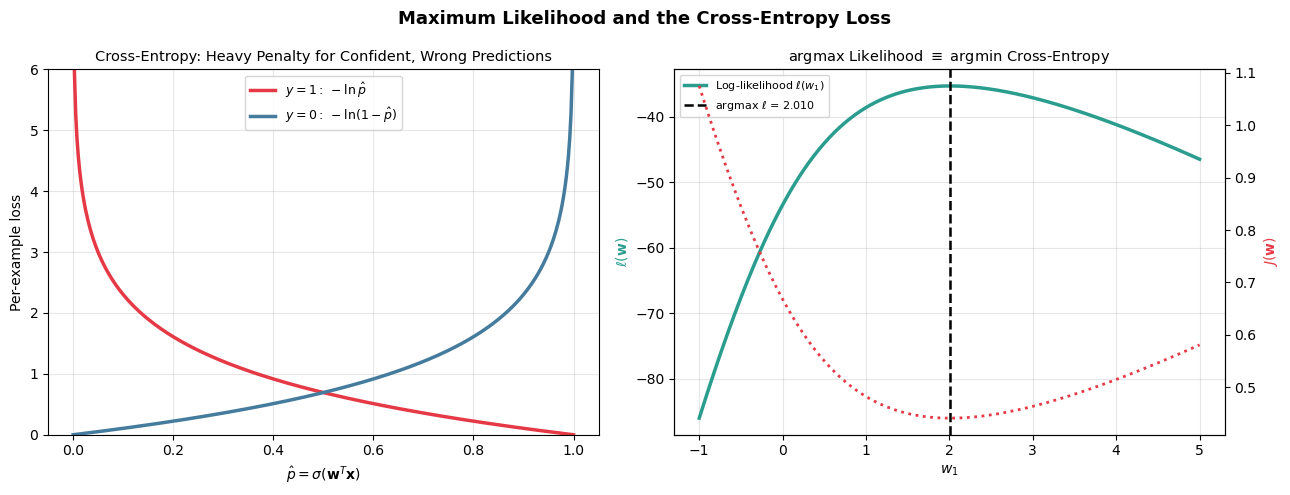

argmax log-likelihood at w1 = 2.0100
argmin cross-entropy  at w1 = 2.0100  (must match)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

p_hat = np.linspace(1e-4, 1-1e-4, 400)
loss_y1 = -np.log(p_hat)       # cost paid when the true label is y=1
loss_y0 = -np.log(1-p_hat)     # cost paid when the true label is y=0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(p_hat, loss_y1, '#E63946', lw=2.5, label=r'$y=1:\; -\ln\hat p$')
ax.plot(p_hat, loss_y0, '#457B9D', lw=2.5, label=r'$y=0:\; -\ln(1-\hat p)$')
ax.set_ylim(0, 6)
ax.set_xlabel(r'$\hat p = \sigma(\mathbf{w}^T\mathbf{x})$'); ax.set_ylabel('Per-example loss')
ax.set_title('Cross-Entropy: Heavy Penalty for Confident, Wrong Predictions', fontsize=10.5)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# --- Verify: argmax likelihood == argmin cross-entropy, sweeping a 1D slice through w-space ---
np.random.seed(21)
N = 80
X_raw = np.random.randn(N, 1)
w_true = np.array([0.4, 2.2])
X = np.hstack([np.ones((N, 1)), X_raw])
y = (sigmoid(X @ w_true) > np.random.rand(N)).astype(float)

w1_range = np.linspace(-1, 5, 300)
log_lik, cross_ent = [], []
for w1 in w1_range:
    w = np.array([w_true[0], w1])
    p = sigmoid(X @ w)
    p = np.clip(p, 1e-12, 1-1e-12)          # numerical safety: avoid log(0)
    ll = np.sum(y*np.log(p) + (1-y)*np.log(1-p))
    log_lik.append(ll)
    cross_ent.append(-ll/N)

ax2 = axes[1]
ax2.plot(w1_range, log_lik, '#2A9D8F', lw=2.5, label=r'Log-likelihood $\ell(w_1)$')
ax2.axvline(w1_range[np.argmax(log_lik)], color='black', lw=1.8, linestyle='--',
            label=f'argmax $\\ell$ = {w1_range[np.argmax(log_lik)]:.3f}')
ax2b = ax2.twinx()
ax2b.plot(w1_range, cross_ent, '#E63946', lw=2, linestyle=':', label=r'Cross-entropy $J(w_1)$')
ax2.set_xlabel('$w_1$'); ax2.set_ylabel(r'$\ell(\mathbf{w})$', color='#2A9D8F')
ax2b.set_ylabel(r'$J(\mathbf{w})$', color='#E63946')
ax2.set_title('argmax Likelihood $\\equiv$ argmin Cross-Entropy', fontsize=10.5)
ax2.legend(loc='upper left', fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Maximum Likelihood and the Cross-Entropy Loss', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'argmax log-likelihood at w1 = {w1_range[np.argmax(log_lik)]:.4f}')
print(f'argmin cross-entropy  at w1 = {w1_range[np.argmin(cross_ent)]:.4f}  (must match)')


---
## 6. Convexity: The Hessian of the Log-Likelihood

Unlike RSS (`06_linear_regression`, Section 4), $J(\mathbf{w})$ has **no closed-form minimizer** because $\sigma(\cdot)$ is nonlinear inside the sum. Before searching iteratively, we must confirm the loss is convex — otherwise gradient-based methods could get stuck in local minima.

### Gradient (full derivation in Section 7)

$$\nabla_\mathbf{w} J(\mathbf{w}) = \frac{1}{N}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y}), \qquad \hat{\mathbf{p}}=\sigma(\mathbf{X}\mathbf{w})$$

### Hessian

Differentiating again (using $\sigma'(z)=\sigma(z)(1-\sigma(z))$ through every $\hat p_i$):

$$\boxed{\mathbf{H} = \nabla^2_\mathbf{w} J(\mathbf{w}) = \frac{1}{N}\mathbf{X}^T\mathbf{S}\mathbf{X}, \qquad \mathbf{S}=\text{diag}\big(\hat p_i(1-\hat p_i)\big)_{i=1}^N}$$

### Proof of Convexity (Positive Semi-Definiteness)

For any $\mathbf{v}\in\mathbb{R}^{d+1}$:

$$\mathbf{v}^T\mathbf{H}\mathbf{v} = \frac{1}{N}\mathbf{v}^T\mathbf{X}^T\mathbf{S}\mathbf{X}\mathbf{v} = \frac{1}{N}(\mathbf{X}\mathbf{v})^T\mathbf{S}(\mathbf{X}\mathbf{v}) = \frac{1}{N}\sum_{i=1}^N \underbrace{\hat p_i(1-\hat p_i)}_{\geq 0 \text{ since } \hat p_i\in(0,1)}\,(\mathbf{x}_i^T\mathbf{v})^2 \geq 0$$

Since $\hat p_i\in(0,1)$ strictly, every diagonal entry of $\mathbf{S}$ is strictly positive, so $\mathbf{H}\succeq\mathbf{0}$ always (and $\mathbf{H}\succ\mathbf{0}$ whenever $\mathbf{X}$ has full column rank). **$J(\mathbf{w})$ is convex — every stationary point is a global minimum.** $\blacksquare$

> **Contrast with RSS+sigmoid:** naively plugging $\sigma(\mathbf{w}^T\mathbf{x})$ into the *squared* loss $\|\mathbf{y}-\sigma(\mathbf{X}\mathbf{w})\|_2^2$ produces a Hessian that is **not** guaranteed PSD — that surface can have multiple local minima. Cross-entropy is precisely the loss that restores convexity for a sigmoidal predictor.


=== Hessian PSD Check (Cross-Entropy) ===
w=[-1.51 -1.02 -0.05]  min eigenvalue = 0.072386  (PSD: True)
w=[-1.92 -1.    1.88]  min eigenvalue = 0.030006  (PSD: True)
w=[-2.45  0.74  2.36]  min eigenvalue = 0.019060  (PSD: True)
w=[-2.15  2.19  0.01]  min eigenvalue = 0.027563  (PSD: True)
w=[-1.07  1.74  0.15]  min eigenvalue = 0.061364  (PSD: True)


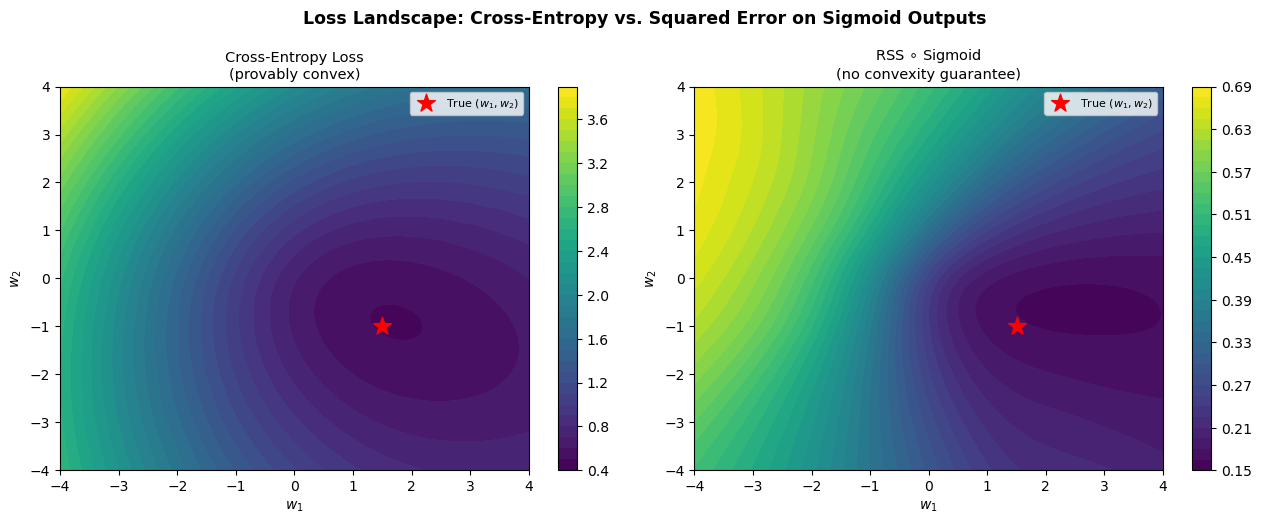

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

np.random.seed(13)
N, d = 60, 2
X = np.hstack([np.ones((N, 1)), np.random.randn(N, d)])
w_true = np.array([0.3, 1.5, -1.0])
y = (sigmoid(X @ w_true) > np.random.rand(N)).astype(float)

def cross_entropy(w):
    p = np.clip(sigmoid(X @ w), 1e-12, 1-1e-12)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def rss_sigmoid(w):
    p = sigmoid(X @ w)
    return np.mean((y - p)**2)

def hessian_cross_entropy(w):
    p = sigmoid(X @ w)
    S = np.diag(p * (1 - p))          # reweighting matrix, one entry per sample
    return (X.T @ S @ X) / N

# --- Check 1: the cross-entropy Hessian is PSD at several random points ---
print('=== Hessian PSD Check (Cross-Entropy) ===')
for trial in range(5):
    w_rand = np.random.randn(d+1) * 2
    H = hessian_cross_entropy(w_rand)
    eigs = np.linalg.eigvalsh(H)
    print(f'w={w_rand.round(2)}  min eigenvalue = {eigs.min():.6f}  (PSD: {eigs.min() >= -1e-10})')

# --- Check 2: visualize the convex bowl (cross-entropy) vs. the RSS+sigmoid surface ---
w0_r = np.linspace(-4, 4, 100)
w1_r = np.linspace(-4, 4, 100)
W0, W1 = np.meshgrid(w0_r, w1_r)
CE, RSSs = np.zeros_like(W0), np.zeros_like(W0)
for i in range(100):
    for j in range(100):
        w = np.array([w_true[0], W0[i, j], W1[i, j]])
        CE[i, j] = cross_entropy(w)
        RSSs[i, j] = rss_sigmoid(w)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
for ax, surf, title in zip(axes, [CE, RSSs],
                            ['Cross-Entropy Loss\n(provably convex)',
                             'RSS $\\circ$ Sigmoid\n(no convexity guarantee)']):
    cp = ax.contourf(W0, W1, surf, levels=40, cmap='viridis')
    plt.colorbar(cp, ax=ax)
    ax.scatter(w_true[1], w_true[2], s=180, color='red', marker='*', zorder=5, label='True $(w_1,w_2)$')
    ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
    ax.set_title(title, fontsize=10.5); ax.legend(fontsize=8)

plt.suptitle('Loss Landscape: Cross-Entropy vs. Squared Error on Sigmoid Outputs', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 7. Gradient of the Log-Likelihood — No Closed Form

### Full Derivation

For a single example, with $z=\mathbf{w}^T\mathbf{x}$ and using $\sigma'(z)=\sigma(z)(1-\sigma(z))$:

$$\frac{\partial}{\partial\mathbf{w}}\Big[y\ln\sigma(z)+(1-y)\ln(1-\sigma(z))\Big] = \left[\frac{y}{\sigma(z)} - \frac{1-y}{1-\sigma(z)}\right]\sigma(z)(1-\sigma(z))\,\mathbf{x}$$

$$= \big[y(1-\sigma(z)) - (1-y)\sigma(z)\big]\mathbf{x} = (y-\sigma(z))\,\mathbf{x}$$

Summing over $N$ examples and flipping the sign for the *negative* log-likelihood $J(\mathbf{w})$:

$$\boxed{\nabla_\mathbf{w} J(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^N\big(\sigma(\mathbf{w}^T\mathbf{x}_i)-y_i\big)\mathbf{x}_i = \frac{1}{N}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y})}$$

**Remarkable observation:** this has *exactly the same form* as the OLS gradient from `06_linear_regression`, $\nabla_\mathbf{w} L = \frac{1}{N}\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y})$ — "prediction minus target," weighted by $\mathbf{x}_i$. The only difference is that the prediction is now $\sigma(\mathbf{X}\mathbf{w})$ instead of the raw linear score $\mathbf{X}\mathbf{w}$.

### Why We Cannot Just Set $\nabla J=\mathbf{0}$ and Solve

$$\mathbf{X}^T\sigma(\mathbf{X}\mathbf{w}) = \mathbf{X}^T\mathbf{y}$$

$\sigma(\cdot)$ is applied element-wise **inside a nonlinear function of $\mathbf{w}$** — this is a *transcendental* equation, not a linear one. There is no algebraic manipulation that isolates $\mathbf{w}$. We must minimize $J(\mathbf{w})$ iteratively.


In [7]:
import numpy as np

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(w, X, y):
    p = np.clip(sigmoid(X @ w), 1e-12, 1-1e-12)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def analytic_grad(w, X, y):
    """Closed-form gradient derived above: X^T (p_hat - y) / N."""
    p = sigmoid(X @ w)
    return X.T @ (p - y) / len(y)

def numeric_grad(w, X, y, h=1e-6):
    """Central finite-difference gradient, used only to validate the closed form."""
    g = np.zeros_like(w)
    for j in range(len(w)):
        w_plus, w_minus = w.copy(), w.copy()
        w_plus[j] += h; w_minus[j] -= h
        g[j] = (cross_entropy(w_plus, X, y) - cross_entropy(w_minus, X, y)) / (2*h)
    return g

np.random.seed(17)
N, d = 100, 4
X = np.hstack([np.ones((N, 1)), np.random.randn(N, d)])
w_true = np.array([0.5, 1.2, -0.8, 2.0, -1.5])
y = (sigmoid(X @ w_true) > np.random.rand(N)).astype(float)

w_test = np.random.randn(d+1)
g_an = analytic_grad(w_test, X, y)
g_nm = numeric_grad(w_test, X, y)

print('=== Gradient Check: Analytic vs. Finite Differences ===')
print(f'{"Component":>10} | {"Analytic":>12} | {"Numerical":>12} | {"|diff|":>10}')
print('-'*52)
for j in range(d+1):
    print(f'  w_{j}       | {g_an[j]:>12.8f} | {g_nm[j]:>12.8f} | {abs(g_an[j]-g_nm[j]):>10.2e}')
print(f'\nMax abs error: {np.max(np.abs(g_an-g_nm)):.2e}   (should be ~1e-9 or smaller)')


=== Gradient Check: Analytic vs. Finite Differences ===
 Component |     Analytic |    Numerical |     |diff|
----------------------------------------------------
  w_0       |   0.02715084 |   0.02715084 |   1.30e-10
  w_1       |  -0.13225138 |  -0.13225138 |   8.47e-11
  w_2       |   0.20095725 |   0.20095725 |   7.22e-11
  w_3       |  -0.29157068 |  -0.29157068 |   5.65e-11
  w_4       |  -0.19621803 |  -0.19621803 |   1.85e-10

Max abs error: 1.85e-10   (should be ~1e-9 or smaller)


---
## 8. Newton-Raphson & Iteratively Reweighted Least Squares (IRLS)

Newton's method uses **curvature** (the Hessian from Section 6) for faster convergence than plain gradient descent:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \big[\mathbf{H}^{(t)}\big]^{-1}\nabla_\mathbf{w} J(\mathbf{w}^{(t)})$$

Substituting $\mathbf{H}=\frac{1}{N}\mathbf{X}^T\mathbf{S}\mathbf{X}$ and $\nabla J=\frac{1}{N}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y})$:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - (\mathbf{X}^T\mathbf{S}\mathbf{X})^{-1}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y})$$

### Reformulating as Weighted Least Squares

Define the **working response** $\mathbf{z} = \mathbf{X}\mathbf{w}^{(t)} + \mathbf{S}^{-1}(\mathbf{y}-\hat{\mathbf{p}})$. Substitution (Bishop, Eq. 4.99–4.100 [3]) shows the Newton step is **exactly** the solution of a weighted least-squares problem:

$$\boxed{\mathbf{w}^{(t+1)} = (\mathbf{X}^T\mathbf{S}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{S}\mathbf{z}}$$

This is **Iteratively Reweighted Least Squares (IRLS)**: at every step, solve a weighted linear regression (weights $\mathbf{S}$ depend on the *current* $\mathbf{w}$, hence "reweighted"), then update the weights and repeat. It converges in far fewer iterations than gradient descent because it exploits second-order information — but each step costs $\mathcal{O}(d^3)$ for the matrix solve (Golub & Van Loan [7]), just like the Normal Equations in `06_linear_regression`.

> **ML Bridge:** IRLS literally *reduces logistic regression to a sequence of linear-regression problems* — the Normal-Equations machinery from `06_linear_regression` reappears verbatim inside the loop.


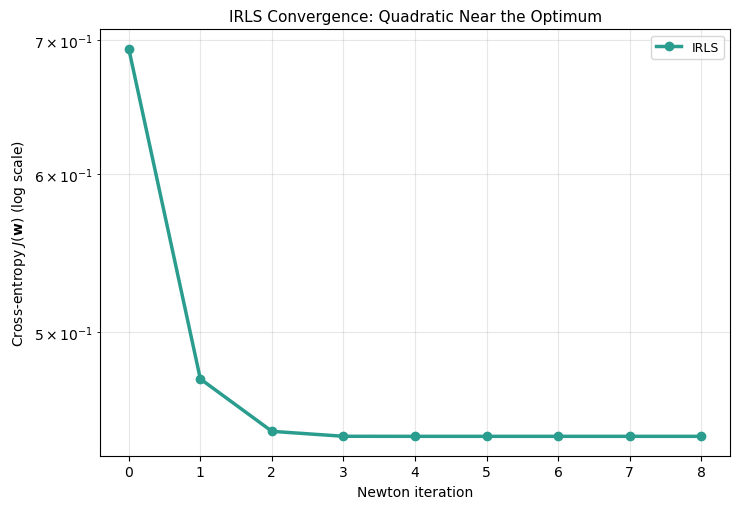

=== IRLS Result ===
True w:      [ 0.5  1.8 -1.2  0.9]
IRLS w*:     [ 0.4772  1.8874 -1.0975  0.7383]
Converged in 8 Newton steps, final loss = 0.44346073


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(w, X, y):
    p = np.clip(sigmoid(X @ w), 1e-12, 1-1e-12)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def irls(X, y, n_iter=10, ridge=1e-8):
    """Iteratively Reweighted Least Squares: Newton's method rewritten as
    a sequence of weighted linear regressions (see the derivation above)."""
    N, D = X.shape
    w = np.zeros(D)
    losses = [cross_entropy(w, X, y)]
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        S = p * (1 - p)
        S = np.clip(S, 1e-8, None)               # numerical floor: avoid a singular X^T S X
        z = X @ w + (y - p) / S                   # working response
        XtSX = (X.T * S) @ X + ridge * np.eye(D)  # weighted Gram matrix X^T S X
        XtSz = (X.T * S) @ z
        w = np.linalg.solve(XtSX, XtSz)
        losses.append(cross_entropy(w, X, y))
    return w, np.array(losses)

np.random.seed(23)
N, d = 200, 3
X = np.hstack([np.ones((N, 1)), np.random.randn(N, d)])
w_true = np.array([0.5, 1.8, -1.2, 0.9])
y = (sigmoid(X @ w_true) > np.random.rand(N)).astype(float)

w_irls, losses_irls = irls(X, y, n_iter=8)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.semilogy(losses_irls, '#2A9D8F', lw=2.5, marker='o', ms=6, label='IRLS')
ax.set_xlabel('Newton iteration'); ax.set_ylabel('Cross-entropy $J(\\mathbf{w})$ (log scale)')
ax.set_title('IRLS Convergence: Quadratic Near the Optimum', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('=== IRLS Result ===')
print(f'True w:      {w_true}')
print(f'IRLS w*:     {w_irls.round(4)}')
print(f'Converged in {len(losses_irls)-1} Newton steps, final loss = {losses_irls[-1]:.8f}')


---
## 9. Gradient Descent for Logistic Regression

When $d$ is large, forming $(\mathbf{X}^T\mathbf{S}\mathbf{X})^{-1}$ at every IRLS step ($\mathcal{O}(d^3)$) is too costly — exactly the motivation from `06_linear_regression`, Section 8. Plain (first-order) gradient descent applies unchanged, using the gradient derived in Section 7:

$$\boxed{\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \frac{\eta}{N}\,\mathbf{X}^T\big(\sigma(\mathbf{X}\mathbf{w}^{(t)})-\mathbf{y}\big)}$$

Since $J(\mathbf{w})$ is convex (Section 6) but *not* quadratic, gradient descent no longer converges in a single step along perfectly elliptical contours — convergence is geometric in the loss rather than exact after one Newton step. Per-iteration cost is $\mathcal{O}(Nd)$, versus IRLS's $\mathcal{O}(Nd^2+d^3)$: many cheap steps vs. a few expensive ones.


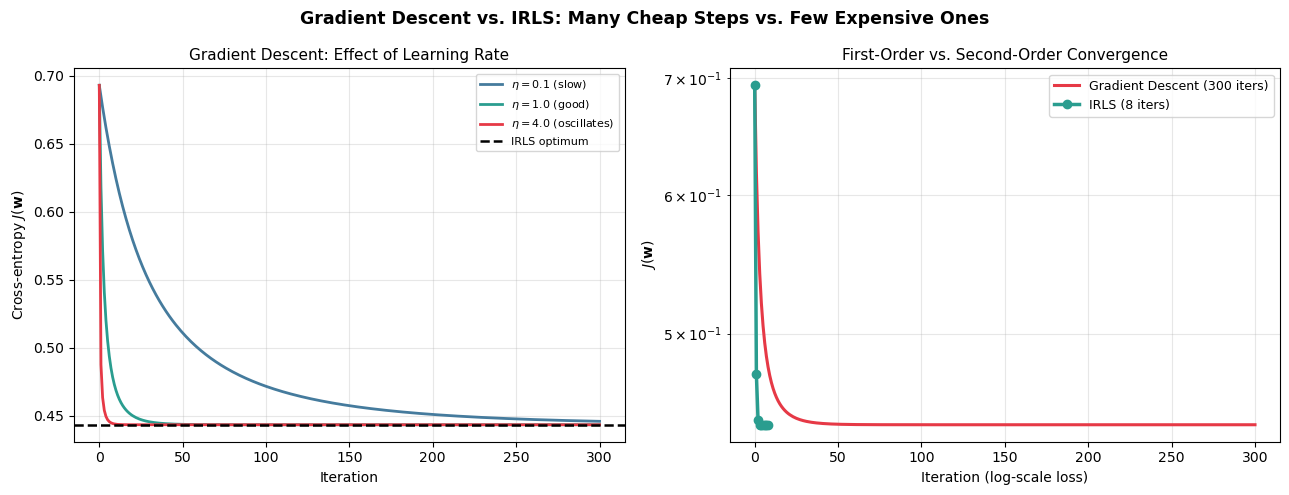

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(w, X, y):
    p = np.clip(sigmoid(X @ w), 1e-12, 1-1e-12)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def gradient_descent(X, y, lr, n_iter=400):
    w = np.zeros(X.shape[1])
    losses = [cross_entropy(w, X, y)]
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        w = w - lr * (X.T @ (p - y)) / len(y)
        losses.append(cross_entropy(w, X, y))
    return w, np.array(losses)

def irls(X, y, n_iter=8, ridge=1e-8):
    N, D = X.shape
    w = np.zeros(D)
    losses = [cross_entropy(w, X, y)]
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        S = np.clip(p * (1 - p), 1e-8, None)
        z = X @ w + (y - p) / S
        w = np.linalg.solve((X.T * S) @ X + ridge*np.eye(D), (X.T * S) @ z)
        losses.append(cross_entropy(w, X, y))
    return w, np.array(losses)

np.random.seed(23)
N, d = 200, 3
X = np.hstack([np.ones((N, 1)), np.random.randn(N, d)])
w_true = np.array([0.5, 1.8, -1.2, 0.9])
y = (sigmoid(X @ w_true) > np.random.rand(N)).astype(float)

_, losses_irls = irls(X, y, n_iter=8)
lrs    = [0.1, 1.0, 4.0]
labels = [r'$\eta=0.1$ (slow)', r'$\eta=1.0$ (good)', r'$\eta=4.0$ (oscillates)']
colors = ['#457B9D', '#2A9D8F', '#E63946']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for lr, lbl, c in zip(lrs, labels, colors):
    _, losses_gd = gradient_descent(X, y, lr, n_iter=300)
    ax.plot(losses_gd, color=c, lw=2, label=lbl)
ax.axhline(losses_irls[-1], color='black', lw=1.8, linestyle='--', label='IRLS optimum')
ax.set_xlabel('Iteration'); ax.set_ylabel('Cross-entropy $J(\\mathbf{w})$')
ax.set_title('Gradient Descent: Effect of Learning Rate', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
_, losses_gd_good = gradient_descent(X, y, lr=1.0, n_iter=300)
ax2.semilogy(losses_gd_good, '#E63946', lw=2.2, label=f'Gradient Descent ({len(losses_gd_good)-1} iters)')
ax2.semilogy(losses_irls, '#2A9D8F', lw=2.5, marker='o', ms=6, label=f'IRLS ({len(losses_irls)-1} iters)')
ax2.set_xlabel('Iteration (log-scale loss)'); ax2.set_ylabel('$J(\\mathbf{w})$')
ax2.set_title('First-Order vs. Second-Order Convergence', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, which='both')

plt.suptitle('Gradient Descent vs. IRLS: Many Cheap Steps vs. Few Expensive Ones', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 10. $L_2$-Regularized Logistic Regression — MAP Estimation

Exactly as in `06_linear_regression`, Section 12 (Ridge), place a zero-mean Gaussian **prior** on the weights: $\mathbf{w}\sim\mathcal{N}(\mathbf{0},\tau^2\mathbf{I})$. By Bayes' rule, the **posterior** is:

$$p(\mathbf{w}\mid\mathcal{D}) \propto p(\mathcal{D}\mid\mathbf{w})\,p(\mathbf{w})$$

Taking the negative log and dropping constants, **Maximum A Posteriori (MAP)** estimation becomes:

$$\boxed{J_{\text{Ridge}}(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^N\Big[y_i\ln\hat p_i+(1-y_i)\ln(1-\hat p_i)\Big] + \frac{\lambda}{2N}\|\mathbf{w}\|_2^2}, \qquad \lambda=\frac{1}{\tau^2}$$

Gradient (the bias term $w_0$ is conventionally **not** penalized):

$$\nabla_\mathbf{w} J_{\text{Ridge}} = \frac{1}{N}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y}) + \frac{\lambda}{N}\mathbf{w}$$

### Effect on the Hessian and on Separability

$$\mathbf{H}_{\text{Ridge}} = \frac{1}{N}\mathbf{X}^T\mathbf{S}\mathbf{X} + \frac{\lambda}{N}\mathbf{I} \;\succ\; \mathbf{0} \quad\text{(strictly positive definite for any }\lambda>0\text{)}$$

This fixes a pathology unique to logistic regression: with **perfectly separable data**, the unregularized $\|\mathbf{w}\|_2\to\infty$ (the sigmoid is pushed toward a step function to make $\hat p_i\to y_i$ exactly, and the likelihood keeps increasing forever — Bishop, Section 4.3.2 [3]). The $L_2$ penalty caps $\|\mathbf{w}\|_2$ and guarantees a finite, unique optimum.


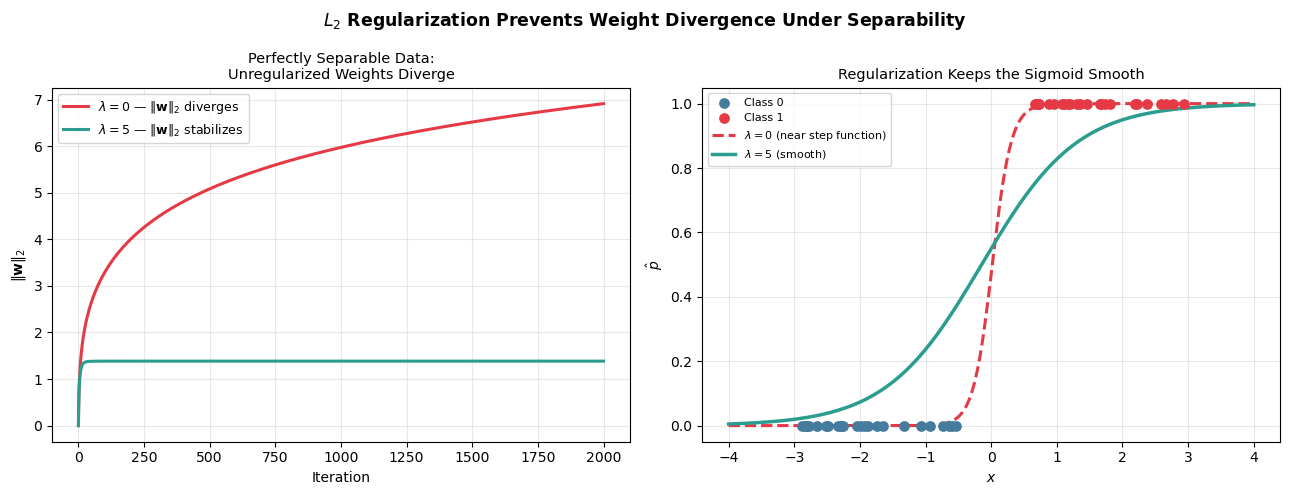

||w|| after 2000 GD steps, lambda=0: 6.91  (still growing)
||w|| after 2000 GD steps, lambda=5: 1.3843  (converged)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(w, X, y, lam=0.0):
    p = np.clip(sigmoid(X @ w), 1e-12, 1-1e-12)
    ce = -np.mean(y*np.log(p) + (1-y)*np.log(1-p))
    reg = lam/(2*len(y)) * np.sum(w[1:]**2)   # bias w[0] is excluded from the penalty
    return ce + reg

def gd_logistic(X, y, lr, lam, n_iter):
    N, D = X.shape
    w = np.zeros(D)
    norms, losses = [np.linalg.norm(w)], [cross_entropy(w, X, y, lam)]
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        reg_grad = np.concatenate([[0.0], w[1:]]) * lam / N   # no penalty on the bias
        w = w - lr * ((X.T @ (p - y)) / N + reg_grad)
        norms.append(np.linalg.norm(w))
        losses.append(cross_entropy(w, X, y, lam))
    return w, np.array(norms), np.array(losses)

# Perfectly separable 1D data by construction: a clear gap between the two classes
np.random.seed(31)
x0 = np.random.uniform(-3, -0.5, 25)
x1 = np.random.uniform(0.5, 3, 25)
X_raw = np.concatenate([x0, x1])
y = np.concatenate([np.zeros(25), np.ones(25)])
X = np.column_stack([np.ones_like(X_raw), X_raw])

w_noreg, norms_noreg, _ = gd_logistic(X, y, lr=0.5, lam=0.0, n_iter=2000)
w_reg,   norms_reg,   _ = gd_logistic(X, y, lr=0.5, lam=5.0, n_iter=2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(norms_noreg, '#E63946', lw=2.2, label=r'$\lambda=0$ — $\|\mathbf{w}\|_2$ diverges')
ax.plot(norms_reg,   '#2A9D8F', lw=2.2, label=r'$\lambda=5$ — $\|\mathbf{w}\|_2$ stabilizes')
ax.set_xlabel('Iteration'); ax.set_ylabel(r'$\|\mathbf{w}\|_2$')
ax.set_title('Perfectly Separable Data:\nUnregularized Weights Diverge', fontsize=10.5)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
x_plot = np.linspace(-4, 4, 300)
X_plot = np.column_stack([np.ones_like(x_plot), x_plot])
ax2.scatter(x0, np.zeros_like(x0), s=45, color='#457B9D', zorder=5, label='Class 0')
ax2.scatter(x1, np.ones_like(x1), s=45, color='#E63946', zorder=5, label='Class 1')
ax2.plot(x_plot, sigmoid(X_plot @ w_noreg), '#E63946', lw=2.2, linestyle='--', label=r'$\lambda=0$ (near step function)')
ax2.plot(x_plot, sigmoid(X_plot @ w_reg), '#2A9D8F', lw=2.5, label=r'$\lambda=5$ (smooth)')
ax2.set_xlabel('$x$'); ax2.set_ylabel(r'$\hat p$')
ax2.set_title('Regularization Keeps the Sigmoid Smooth', fontsize=10.5)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle(r'$L_2$ Regularization Prevents Weight Divergence Under Separability', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'||w|| after 2000 GD steps, lambda=0: {norms_noreg[-1]:.2f}  (still growing)')
print(f'||w|| after 2000 GD steps, lambda=5: {norms_reg[-1]:.4f}  (converged)')


---
## 11. Multiclass: Softmax Regression

For $K>2$ classes, generalize the sigmoid to the **softmax function**. With one weight vector $\mathbf{w}_k$ per class, define $z_k=\mathbf{w}_k^T\mathbf{x}$ and:

$$\boxed{P(y=k\mid\mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}}$$

**Sanity check ($K=2$):** $P(y=1\mid\mathbf{x})=\dfrac{e^{z_1}}{e^{z_0}+e^{z_1}}=\dfrac{1}{1+e^{-(z_1-z_0)}}=\sigma(z_1-z_0)$ — softmax collapses exactly to the sigmoid of the *difference* of the two scores, recovering binary logistic regression as a special case.

### Cross-Entropy for $K$ Classes

With one-hot labels $y_{ik}\in\{0,1\}$:

$$J(\mathbf{W}) = -\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K y_{ik}\ln\hat p_{ik}$$

### Gradient (same "prediction $-$ target" structure)

$$\nabla_{\mathbf{w}_k} J = \frac{1}{N}\sum_{i=1}^N(\hat p_{ik}-y_{ik})\,\mathbf{x}_i$$

identical in form to Section 7 — the softmax/cross-entropy pair is the natural multiclass generalization of sigmoid/cross-entropy, and both come from the same exponential-family (GLM) construction (Bishop, Section 4.3.4 [3]).


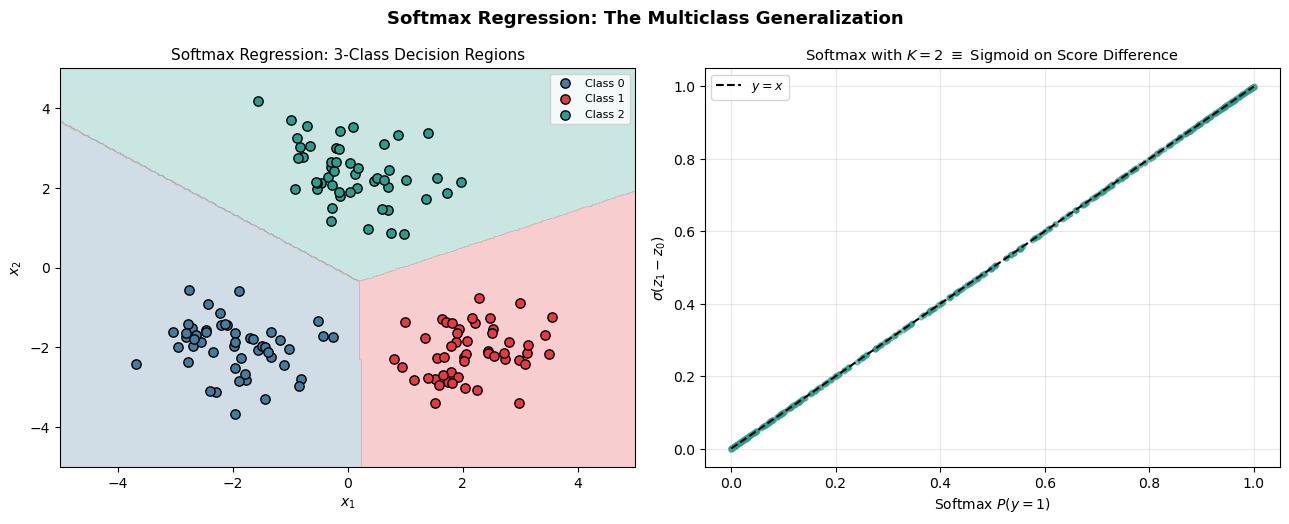

Max |softmax - sigmoid| discrepancy: 2.22e-16


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)   # subtract row-max for numerical stability
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=1, keepdims=True)

def one_hot(y, K):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1
    return Y

def softmax_gd(X, y, K, lr=0.5, n_iter=800):
    """W has one column per class; gradient has the same 'p_hat - y' structure as Section 7."""
    N, D = X.shape
    Y = one_hot(y, K)
    W = np.zeros((D, K))
    for _ in range(n_iter):
        P = softmax(X @ W)
        W = W - lr * (X.T @ (P - Y)) / N
    return W

# 3-class synthetic 2D dataset (three Gaussian blobs)
np.random.seed(4)
N_per = 50
centers = np.array([[-2, -2], [2, -2], [0, 2.2]])
Xs, ys = [], []
for k, c in enumerate(centers):
    Xs.append(np.random.multivariate_normal(c, 0.5*np.eye(2), N_per))
    ys.append(np.full(N_per, k))
X_raw, y = np.vstack(Xs), np.concatenate(ys)
X = np.hstack([np.ones((len(y), 1)), X_raw])

W = softmax_gd(X, y, K=3, lr=0.5, n_iter=800)

xx, yy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
grid = np.column_stack([np.ones(xx.size), xx.ravel(), yy.ravel()])
pred = softmax(grid @ W).argmax(axis=1).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
ax = axes[0]
ax.contourf(xx, yy, pred, levels=[-0.5, 0.5, 1.5, 2.5], colors=['#457B9D', '#E63946', '#2A9D8F'], alpha=0.25)
colors_pt = ['#457B9D', '#E63946', '#2A9D8F']
for k in range(3):
    ax.scatter(*X_raw[y == k].T, s=45, color=colors_pt[k], edgecolor='k', zorder=5, label=f'Class {k}')
ax.set_title('Softmax Regression: 3-Class Decision Regions', fontsize=11)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(fontsize=8)

# Sanity check: softmax collapses to the sigmoid of the score difference when K=2
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

np.random.seed(9)
z0_vals = np.random.randn(500) * 2
z1_vals = np.random.randn(500) * 2
p1_softmax = np.exp(z1_vals) / (np.exp(z0_vals) + np.exp(z1_vals))
p1_sigmoid = sigmoid(z1_vals - z0_vals)

ax2 = axes[1]
ax2.scatter(p1_softmax, p1_sigmoid, s=12, alpha=0.5, color='#2A9D8F')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='$y=x$')
ax2.set_xlabel('Softmax $P(y=1)$'); ax2.set_ylabel(r'$\sigma(z_1-z_0)$')
ax2.set_title('Softmax with $K=2$ $\\equiv$ Sigmoid on Score Difference', fontsize=10.5)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle('Softmax Regression: The Multiclass Generalization', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Max |softmax - sigmoid| discrepancy: {np.max(np.abs(p1_softmax - p1_sigmoid)):.2e}')


---
## 12. Generative vs. Discriminative: Naive Bayes vs. Logistic Regression

Two philosophies for classification (Mitchell [6], Ng — CS229 Part III [1]):

| | Models | Learns |
|---|--------|--------|
| **Generative** (e.g. Gaussian Naive Bayes) | $p(\mathbf{x}\mid y)$ and $p(y)$ | Full data distribution; predicts via Bayes' rule |
| **Discriminative** (Logistic Regression) | $p(y\mid\mathbf{x})$ directly | Only the decision boundary |

### A Deep Connection

Assume a **Gaussian generative model**: $\mathbf{x}\mid y=k\sim\mathcal{N}(\boldsymbol{\mu}_k,\boldsymbol{\Sigma})$ with a **shared** covariance $\boldsymbol\Sigma$ across classes, and prior $P(y=1)=\pi$. Applying Bayes' rule:

$$P(y=1\mid\mathbf{x}) = \frac{\pi\,\mathcal{N}(\mathbf{x};\boldsymbol\mu_1,\boldsymbol\Sigma)}{\pi\,\mathcal{N}(\mathbf{x};\boldsymbol\mu_1,\boldsymbol\Sigma)+(1-\pi)\,\mathcal{N}(\mathbf{x};\boldsymbol\mu_0,\boldsymbol\Sigma)}$$

Expanding the Gaussian densities, the quadratic terms $\mathbf{x}^T\boldsymbol\Sigma^{-1}\mathbf{x}$ **cancel** (shared $\boldsymbol\Sigma$), and after algebra (Bishop, Section 4.2 [3]):

$$\boxed{P(y=1\mid\mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x}+b)}, \qquad \mathbf{w}=\boldsymbol\Sigma^{-1}(\boldsymbol\mu_1-\boldsymbol\mu_0)$$

**A shared-covariance Gaussian generative model produces exactly the sigmoid form of Logistic Regression!** The two models share the same *hypothesis class* but differ in how they fit it:

* **Logistic Regression** directly maximizes the conditional likelihood $\prod P(y_i\mid\mathbf{x}_i;\mathbf{w})$ — fewer assumptions, more robust when the generative assumption is wrong, but needs more data to reach its asymptotic error (Ng, *"On Discriminative vs. Generative Classifiers"*, NeurIPS 2001).
* **Naive Bayes** maximizes the joint likelihood $\prod P(\mathbf{x}_i,y_i)$ — converges faster with limited data when the Gaussian/independence assumptions roughly hold, but is asymptotically biased when they do not.


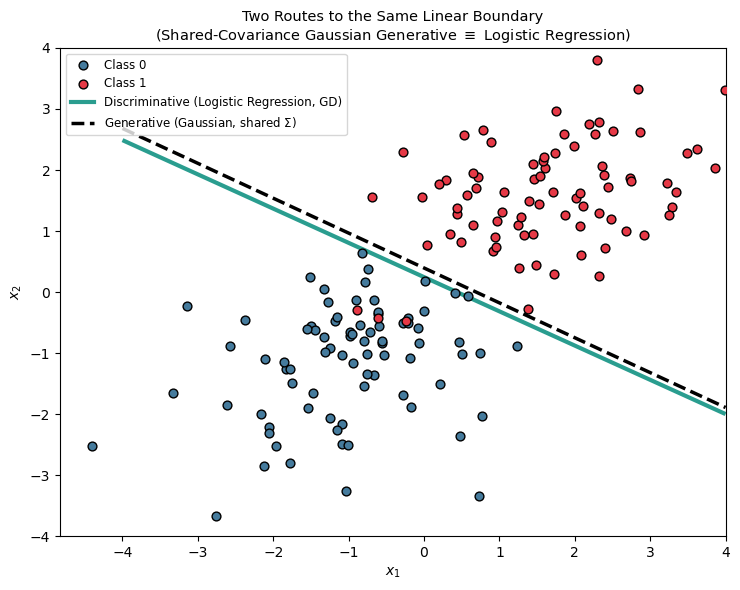

=== Weight Comparison (should point in a similar direction) ===
Logistic Regression w:  [-0.727  1.656  2.953]
Gaussian Generative w:  [-1.126  1.627  2.847]
Cosine similarity of decision directions: 1.0000


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def fit_logistic_gd(X, y, lr=0.5, n_iter=1000):
    w = np.zeros(X.shape[1])
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        w -= lr * (X.T @ (p - y)) / len(y)
    return w

def fit_gaussian_generative(X_raw, y):
    """MLE of a shared-covariance Gaussian generative model, mapped to the
    equivalent sigmoid weights w = Sigma^-1 (mu1 - mu0), b as in Bishop Ch.4."""
    mu0 = X_raw[y == 0].mean(axis=0)
    mu1 = X_raw[y == 1].mean(axis=0)
    N0, N1 = np.sum(y == 0), np.sum(y == 1)
    Sigma = (np.cov((X_raw[y == 0]-mu0).T, bias=True)*N0 +
             np.cov((X_raw[y == 1]-mu1).T, bias=True)*N1) / (N0+N1)
    Sigma_inv = np.linalg.inv(Sigma)
    w = Sigma_inv @ (mu1 - mu0)
    pi = N1 / (N0 + N1)
    b = -0.5*mu1@Sigma_inv@mu1 + 0.5*mu0@Sigma_inv@mu0 + np.log(pi/(1-pi))
    return np.concatenate([[b], w])

np.random.seed(50)
N = 80
mu0, mu1 = np.array([-1, -1]), np.array([1.5, 1.5])
Sigma_true = np.array([[1.0, 0.3], [0.3, 0.8]])
X0 = np.random.multivariate_normal(mu0, Sigma_true, N)
X1 = np.random.multivariate_normal(mu1, Sigma_true, N)
X_raw = np.vstack([X0, X1])
y = np.concatenate([np.zeros(N), np.ones(N)])
X_aug = np.hstack([np.ones((2*N, 1)), X_raw])

w_logreg = fit_logistic_gd(X_aug, y)
w_gen = fit_gaussian_generative(X_raw, y)

xx, yy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
grid_aug = np.column_stack([np.ones(xx.size), xx.ravel(), yy.ravel()])

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(*X0.T, s=40, color='#457B9D', edgecolor='k', zorder=5, label='Class 0')
ax.scatter(*X1.T, s=40, color='#E63946', edgecolor='k', zorder=5, label='Class 1')
ax.contour(xx, yy, (grid_aug @ w_logreg).reshape(xx.shape), levels=[0], colors='#2A9D8F', linewidths=3)
ax.contour(xx, yy, (grid_aug @ w_gen).reshape(xx.shape), levels=[0], colors='black', linewidths=2.5, linestyles='--')
ax.plot([], [], color='#2A9D8F', lw=3, label='Discriminative (Logistic Regression, GD)')
ax.plot([], [], color='black', lw=2.5, linestyle='--', label='Generative (Gaussian, shared $\\Sigma$)')
ax.set_title('Two Routes to the Same Linear Boundary\n(Shared-Covariance Gaussian Generative $\\equiv$ Logistic Regression)', fontsize=10.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print('=== Weight Comparison (should point in a similar direction) ===')
print(f'Logistic Regression w:  {w_logreg.round(3)}')
print(f'Gaussian Generative w:  {w_gen.round(3)}')
cos_sim = (w_logreg[1:] @ w_gen[1:]) / (np.linalg.norm(w_logreg[1:]) * np.linalg.norm(w_gen[1:]))
print(f'Cosine similarity of decision directions: {cos_sim:.4f}')


---
## 13. Evaluation: Confusion Matrix, Precision/Recall, ROC-AUC

Accuracy alone is misleading under **class imbalance**. Given predictions thresholded at $0.5$, build the **confusion matrix**:

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

$$\text{Precision}=\frac{TP}{TP+FP}, \qquad \text{Recall (Sensitivity)}=\frac{TP}{TP+FN}, \qquad F_1=2\cdot\frac{\text{Prec}\cdot\text{Rec}}{\text{Prec}+\text{Rec}}$$

### ROC Curve

Sweeping the decision threshold $\tau\in[0,1]$ (instead of fixing it at $0.5$) traces the **Receiver Operating Characteristic**: True Positive Rate ($=\text{Recall}$) against False Positive Rate $=\dfrac{FP}{FP+TN}$. The **Area Under the Curve (AUC)** is the probability that a randomly chosen positive example is ranked above a randomly chosen negative one — a threshold-independent measure of separability (Hosmer, Lemeshow & Sturdivant [8]).


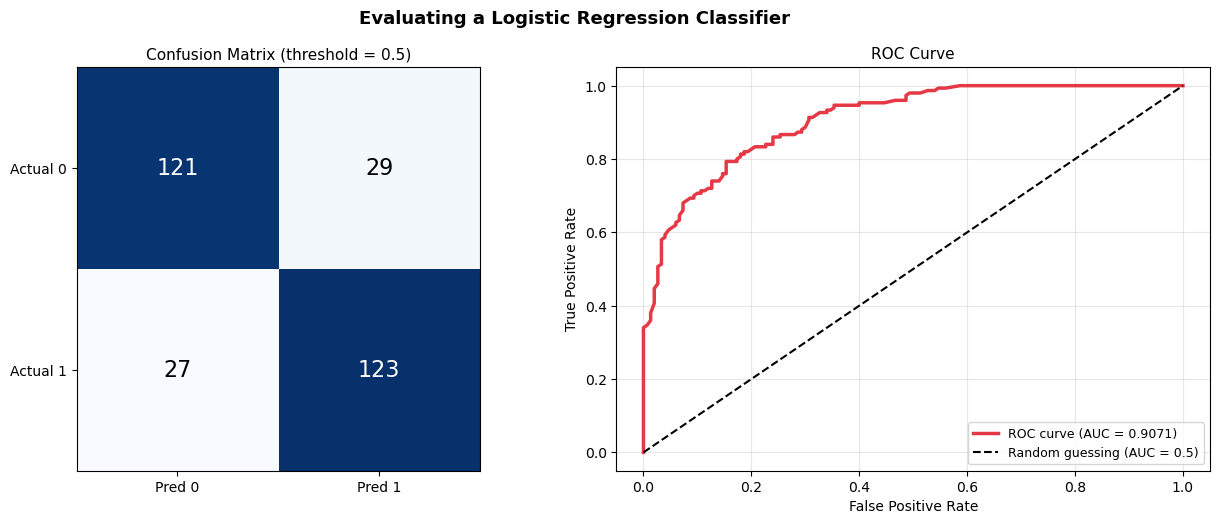

=== Classification Report (threshold = 0.5) ===
Accuracy:  0.8133
Precision: 0.8092
Recall:    0.8200
F1-score:  0.8146
AUC:       0.9071


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def fit_logistic_gd(X, y, lr=0.5, n_iter=1000):
    w = np.zeros(X.shape[1])
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        w -= lr * (X.T @ (p - y)) / len(y)
    return w

def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1)); TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1)); FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def roc_curve_manual(y_true, scores, n_thresh=200):
    """Sweep the threshold from 1 down to 0 and trace (FPR, TPR) -- built from scratch."""
    thresholds = np.linspace(1, 0, n_thresh)
    tpr, fpr = [], []
    P, N = np.sum(y_true == 1), np.sum(y_true == 0)
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)
        tpr.append(TP/P if P > 0 else 0)
        fpr.append(FP/N if N > 0 else 0)
    return np.array(fpr), np.array(tpr), thresholds

# Overlapping (harder) 2-class dataset -- accuracy alone would hide the trade-offs below
np.random.seed(60)
N = 150
X0 = np.random.multivariate_normal([-0.6, -0.6], 1.1*np.eye(2), N)
X1 = np.random.multivariate_normal([0.8, 0.8], 1.1*np.eye(2), N)
X_raw = np.vstack([X0, X1]); y = np.concatenate([np.zeros(N), np.ones(N)])
X = np.hstack([np.ones((2*N, 1)), X_raw])

w = fit_logistic_gd(X, y, lr=0.3, n_iter=2000)
scores = sigmoid(X @ w)
y_pred = (scores >= 0.5).astype(int)

TP, TN, FP, FN = confusion_matrix_manual(y, y_pred)
precision = TP/(TP+FP); recall = TP/(TP+FN); f1 = 2*precision*recall/(precision+recall)
accuracy = (TP+TN)/len(y)

fpr, tpr, _ = roc_curve_manual(y, scores)
auc = np.trapezoid(tpr, fpr)   # trapezoidal integration under the ROC curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
ax = axes[0]
cm = np.array([[TN, FP], [FN, TP]])
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=16,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1']); ax.set_yticklabels(['Actual 0', 'Actual 1'])
ax.set_title('Confusion Matrix (threshold = 0.5)', fontsize=11)

ax2 = axes[1]
ax2.plot(fpr, tpr, '#E63946', lw=2.5, label=f'ROC curve (AUC = {auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random guessing (AUC = 0.5)')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle('Evaluating a Logistic Regression Classifier', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('=== Classification Report (threshold = 0.5) ===')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'AUC:       {auc:.4f}')


---
## 14. Full Comparison: Linear vs. Polynomial vs. Regularized Boundaries

Side by side on the same nonlinearly-separable dataset — the same story as `06_linear_regression`, Section 15, transposed to classification: underfitting with a purely linear boundary, overfitting with an unregularized high-degree polynomial expansion, and a stable fit once $L_2$ regularization is added.


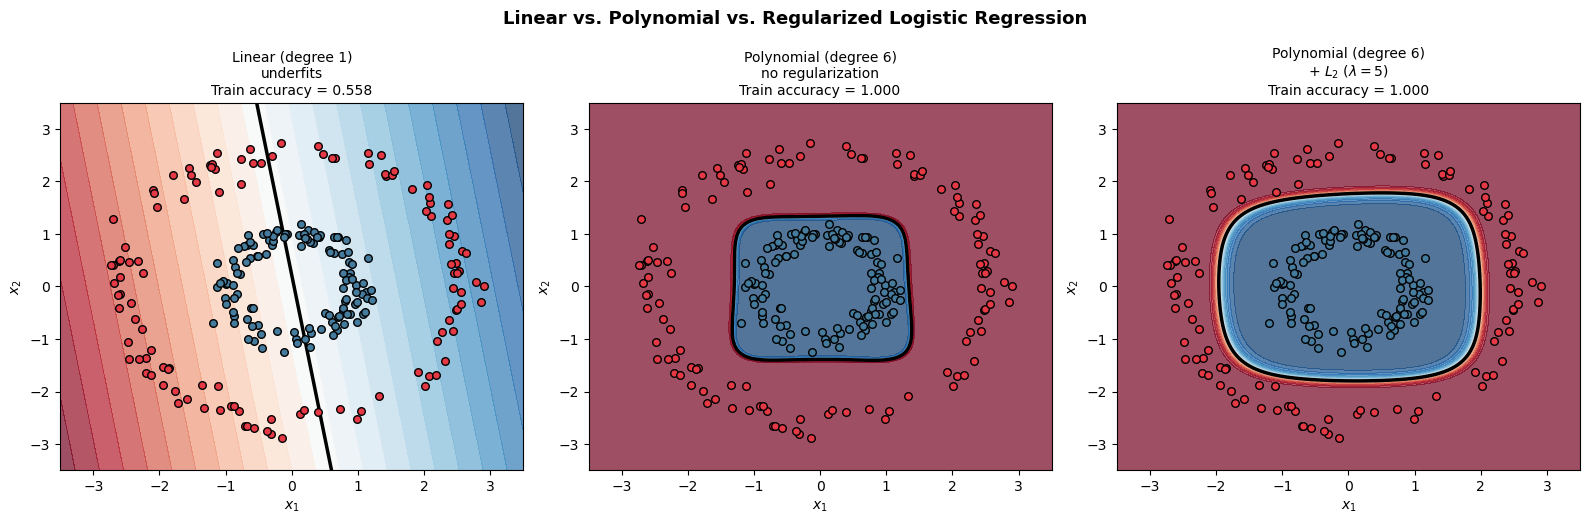

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def poly_features(X_raw, degree):
    """Manual polynomial feature expansion (all monomials up to `degree`),
    the 2D analogue of the Vandermonde matrix from 06_linear_regression, Section 9."""
    N, d = X_raw.shape
    feats = [np.ones(N)]
    for deg in range(1, degree+1):
        for combo in combinations_with_replacement(range(d), deg):
            term = np.ones(N)
            for idx in combo:
                term = term * X_raw[:, idx]
            feats.append(term)
    return np.column_stack(feats)

def fit_logistic_gd(X, y, lr=0.5, n_iter=3000, lam=0.0):
    N, D = X.shape
    w = np.zeros(D)
    for _ in range(n_iter):
        p = sigmoid(X @ w)
        reg = np.concatenate([[0.0], w[1:]]) * lam / N
        w -= lr * ((X.T @ (p - y)) / N + reg)
    return w

# Concentric-circle dataset: not linearly separable
np.random.seed(70)
n_per = 120
theta_in, theta_out = np.random.uniform(0, 2*np.pi, n_per), np.random.uniform(0, 2*np.pi, n_per)
r_in  = np.random.normal(1.0, 0.15, n_per)
r_out = np.random.normal(2.6, 0.15, n_per)
X0 = np.column_stack([r_in*np.cos(theta_in), r_in*np.sin(theta_in)])
X1 = np.column_stack([r_out*np.cos(theta_out), r_out*np.sin(theta_out)])
X_raw = np.vstack([X0, X1]); y = np.concatenate([np.zeros(n_per), np.ones(n_per)])

xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 250), np.linspace(-3.5, 3.5, 250))
grid_raw = np.column_stack([xx.ravel(), yy.ravel()])

configs = [
    ('Linear (degree 1)\nunderfits', 1, 0.0),
    ('Polynomial (degree 6)\nno regularization', 6, 0.0),
    ('Polynomial (degree 6)\n+ $L_2$ ($\\lambda=5$)', 6, 5.0),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, (title, deg, lam) in zip(axes, configs):
    Phi = poly_features(X_raw, deg)
    w = fit_logistic_gd(Phi, y, lr=0.3, n_iter=3000, lam=lam)
    Phi_grid = poly_features(grid_raw, deg)
    P_grid = sigmoid(Phi_grid @ w).reshape(xx.shape)
    train_acc = np.mean((sigmoid(Phi @ w) >= 0.5).astype(int) == y)

    ax.contourf(xx, yy, P_grid, levels=25, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, P_grid, levels=[0.5], colors='black', linewidths=2.5)
    ax.scatter(*X0.T, s=30, color='#457B9D', edgecolor='k', zorder=5)
    ax.scatter(*X1.T, s=30, color='#E63946', edgecolor='k', zorder=5)
    ax.set_title(f'{title}\nTrain accuracy = {train_acc:.3f}', fontsize=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.suptitle('Linear vs. Polynomial vs. Regularized Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Summary

| Concept | Key Formula | Core Insight |
|---------|-------------|---------------|
| Sigmoid | $\sigma(z)=\frac{1}{1+e^{-z}}$ | Maps $\mathbb{R}\to(0,1)$; inverse of the logit |
| Bernoulli model | $P(y\mid\mathbf{x})=\sigma(z)^y(1-\sigma(z))^{1-y}$ | Discrete-target GLM |
| Cross-Entropy | $J=-\frac{1}{N}\sum[y\ln\hat p+(1-y)\ln(1-\hat p)]$ | $\equiv$ negative log-likelihood |
| Gradient | $\nabla J=\frac{1}{N}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y})$ | Same "pred $-$ target" form as OLS |
| Hessian | $\mathbf{H}=\frac{1}{N}\mathbf{X}^T\mathbf{S}\mathbf{X}$, $\mathbf{S}=\text{diag}(\hat p_i(1-\hat p_i))$ | PSD $\Rightarrow$ convex loss |
| IRLS | $\mathbf{w}^{(t+1)}=(\mathbf{X}^T\mathbf{S}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{S}\mathbf{z}$ | Newton's method $\equiv$ weighted LS |
| GD | $\mathbf{w}^{(t+1)}=\mathbf{w}^{(t)}-\frac{\eta}{N}\mathbf{X}^T(\sigma(\mathbf{X}\mathbf{w}^{(t)})-\mathbf{y})$ | First-order, $\mathcal{O}(Nd)$ per step |
| Ridge Logistic | $J_{\text{Ridge}}=J+\frac{\lambda}{2N}\|\mathbf{w}\|_2^2$ | MAP estimation; fixes separability blow-up |
| Softmax | $P(y=k\mid\mathbf{x})=\frac{e^{z_k}}{\sum_j e^{z_j}}$ | Multiclass generalization, $K=2\Rightarrow\sigma$ |
| Gen. vs. Discrim. | Shared-$\Sigma$ Gaussian $\Rightarrow \sigma(\mathbf{w}^T\mathbf{x})$ | Two routes to the same linear boundary |
| ROC-AUC | AUC $=P(\hat p_+ > \hat p_-)$ | Threshold-independent separability |

---

**Next →** `08_svm_and_kernel_methods.ipynb`: Maximum-Margin Classifiers, the Hinge Loss, and the Kernel Trick.
